In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import time

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
import cartopy.crs as ccrs

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


In [3]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp)


# -----------------
#land vs ocean mask, area weighted
ocean_mask = masks.seamask == 1
land_mask = masks.seamask == 0

In [4]:
#weights broadcasted to correct format
weights = np.cos(np.deg2rad(masks.lat))
total = (masks.seamask>=0).weighted(weights).sum()

land_fraction = (land_mask).weighted(weights).sum() / total
ocean_fraction = (ocean_mask).weighted(weights).sum() / total



In [5]:
#load t2m dataset
fp = '/data/jmex/ERA5/monthly/recent/era5_t2m.nc'
t2m = xr.open_dataset(fp).sel(valid_time = slice('1979', None))


#change variable names
t2m = t2m.rename({'latitude':'lat', 'longitude':'lon'})
t2m = t2m.drop_vars(['number', 'expver'])


t2m = t2m.rename({'valid_time':'time'})
t2m['time'] = pd.to_datetime(t2m['time'].values.astype(str), format='%Y-%m-%d')


In [6]:
t2m = t2m.where(ocean_mask, drop=False)

In [7]:
#all but ASO
t2m_noASO = t2m.where(t2m.time.dt.month.isin([1,2,3,4,5,6,7,8,9,10,11,12])).groupby('time.year').mean(dim='time')

In [8]:
t2m_noASO = t2m_noASO.interp(lat=masks.lat, lon=masks.lon, method='nearest')
t2m_noASO = t2m_noASO.weighted(weights).mean(dim=['lat','lon'])


In [9]:
dt2m_noASO = t2m_noASO - t2m_noASO.shift(year=1)

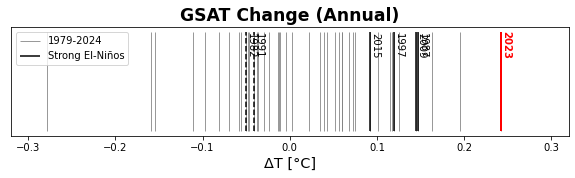

In [10]:

composite_years = [1982, 1987, 1991, 1997, 2015, 2009]
dt2m_noASO_composite = dt2m_noASO.where(dt2m_noASO.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dt2m_noASO.t2m, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dt2m_noASO.sel(year = 1982).t2m, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dt2m_noASO.sel(year = 1987).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt2m_noASO.sel(year = 1991).t2m, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dt2m_noASO.sel(year = 1997).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt2m_noASO.sel(year = 2009).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt2m_noASO.sel(year = 2015).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)


for y in dt2m_noASO_composite.year.values: 
    x = dt2m_noASO.sel(year = y).t2m
    ax.annotate(y, (x, 0.75), rotation = 270)
        

x = dt2m_noASO.sel(year= 2023).t2m
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.vlines(x, ymin=0, ymax = 0, color = 'k', linewidth = 1.5, label = 'Strong El-Niños')
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔT [°C]", fontweight = 'normal')
ax.set_title("GSAT Change (Annual)")
ax.set_xlim(-0.32, .32)

plt.legend(loc = 'upper left')


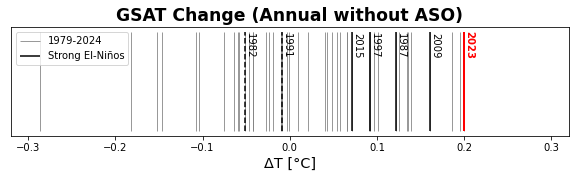

In [11]:

composite_years = [1982, 1987, 1991, 1997, 2015, 2009]
dt2m_noASO_composite = dt2m_noASO.where(dt2m_noASO.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dt2m_noASO.t2m, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dt2m_noASO.sel(year = 1982).t2m, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dt2m_noASO.sel(year = 1987).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt2m_noASO.sel(year = 1991).t2m, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dt2m_noASO.sel(year = 1997).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt2m_noASO.sel(year = 2009).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt2m_noASO.sel(year = 2015).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)


for y in dt2m_noASO_composite.year.values: 
    x = dt2m_noASO.sel(year = y).t2m
    ax.annotate(y, (x, 0.75), rotation = 270)
        

x = dt2m_noASO.sel(year= 2023).t2m
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.vlines(x, ymin=0, ymax = 0, color = 'k', linewidth = 1.5, label = 'Strong El-Niños')
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔT [°C]", fontweight = 'normal')
ax.set_title("GSAT Change (Annual without ASO)")
ax.set_xlim(-0.32, .32)


plt.legend(loc = 'upper left')


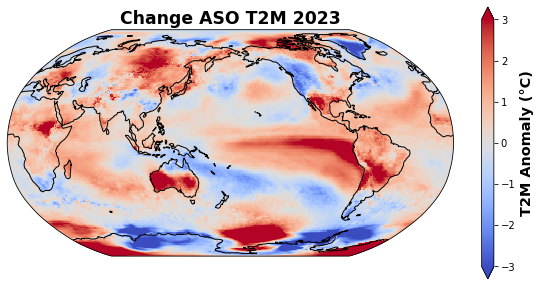

In [42]:
#plot dgmst for 2023 in robinson projection
fig, ax = plt.subplots(figsize=(10,5), subplot_kw={'projection':ccrs.Robinson(central_longitude=180)})
dt2m.sel(year = 2023).t2m.plot.pcolormesh(ax=ax, cmap='coolwarm', transform = ccrs.PlateCarree(),
                                            vmin=-3, vmax=3, cbar_kwargs={'label':'T2M Anomaly (°C)'})
ax.coastlines()
ax.set_title('Change ASO T2M 2023')
plt.show()

In [49]:
GMST = t2m.where(ocean_mask).weighted(weights).mean(dim=['lat', 'lon'], skipna=True) * ocean_fraction
GLST = t2m.where(land_mask).weighted(weights).mean(dim=['lat', 'lon'], skipna=True) * land_fraction

# calculate anomalies
GMST['anom'] = GMST['t2m'] - GMST['t2m'].mean(dim='year')
GLST['anom'] = GLST['t2m'] - GLST['t2m'].mean(dim='year')


/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/numpy/core/_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


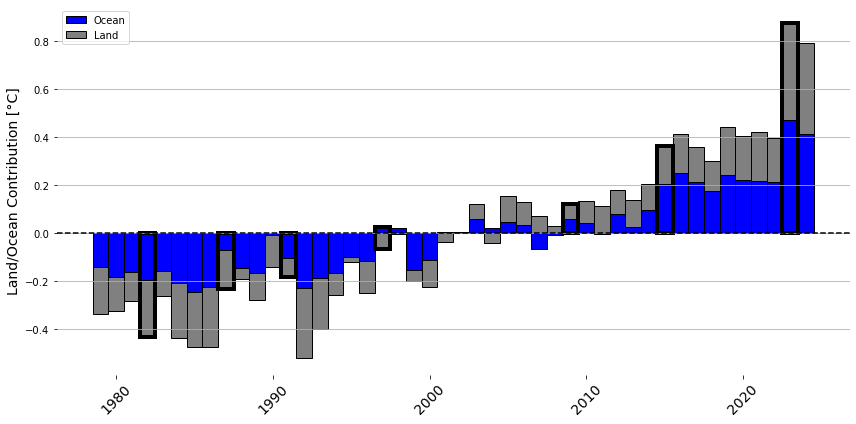

In [50]:
ls = [GMST, GLST]

# make the plot
fig, ax = plt.subplots(1,1, figsize = (12,6))


labels = ['Ocean',  'Land']
colors = ['blue',  'grey']


bottom_pos = np.zeros(len(GMST['year']))
bottom_neg = np.zeros(len(GMST['year']))

for i, r in enumerate(ls):
    values = r['anom'].values
    bottom = np.where(values>=0, bottom_pos, bottom_neg)
    ax.bar(r['year'].values, values, width=1,
           bottom=bottom, label=labels[i], color = colors[i], edgecolor = 'k')
    bottom_pos += np.where(values >= 0, values, 0)
    bottom_neg += np.where(values < 0, values, 0)

    
# Add a dashed line centered on zero
ax.axhline(0, color='black', linestyle='--')

#ax.scatter(sst.year.values, sst.anom.values, color = 'k', zorder = 20, s = 5)


# Add legend, labels, and title
ax.legend()
ax.set_ylabel('SST Anomaly Contributions [K]\n(1991-2020)')
ax.set_title('')
plt.xticks(rotation=45, fontweight = 'normal', size = 14)



# Only display horizontal grid lines and remove the plot frame
ax.yaxis.grid(True)  # Horizontal grid lines
ax.xaxis.grid(False)  # No vertical grid lines


ax.set_ylabel('Land/Ocean Contribution [°C]', fontsize = 14, fontweight = 'normal')

# Define the years of interest and their positions on the x-axis
years_of_interest = [1982, 1987, 1991, 1997, 2009, 2015, 2023]

for year in years_of_interest:
    # Define rectangle parameters: (x, y) for bottom left corner, width, height
    y = bottom_neg[np.where(r.year.values == year)[0]]
    height = -bottom_neg[np.where(r.year.values == year)[0]]+bottom_pos[np.where(r.year.values == year)[0]]
    rect = plt.Rectangle((year-0.5, y), 1, height , linewidth=4, edgecolor='k', facecolor='none')

    # Add the rectangle to the plot
    ax.add_patch(rect)

'''
ax2 = ax.twinx()  # instantiate a second Axes that shares the same x-axis

ax2.set_ylabel('ONI', color='k', fontsize = 12)  # we already handled the x-label with ax1
ax2.tick_params(axis='y', labelcolor='k')
ax2.plot(oni.year,oni.oni9, marker = 'o', c = 'k', linestyle = '--')
#ax.legend()    

ax.set_ylim(-0.5,0.7)
ax2.set_ylim(-5/12 * 6,7/12 *6)
'''
for a in [ax]:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['left'].set_visible(False)
    a.spines['bottom'].set_visible(False)

fig.tight_layout()

plt.show()


    


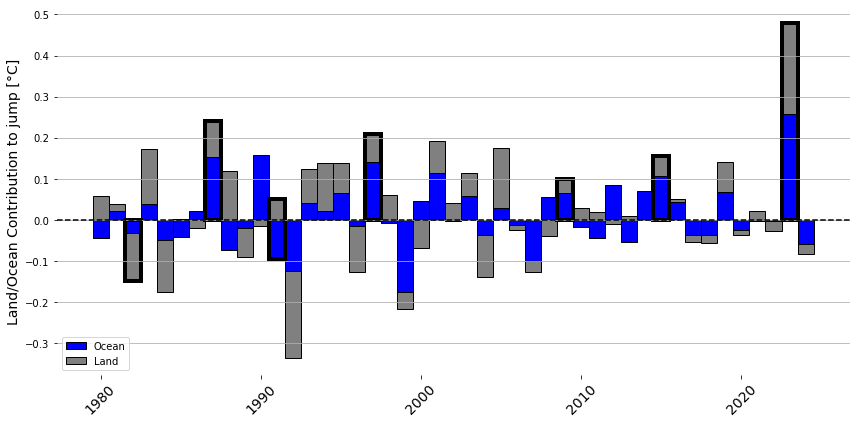

In [51]:

# make the plot
fig, ax = plt.subplots(1,1, figsize = (12,6))



bottom_pos = np.zeros(len(GMST['year']))
bottom_neg = np.zeros(len(GMST['year']))

for i, r in enumerate(ls):
    dr = r - r.shift(year=1)
    values = dr['anom'].values
    bottom = np.where(values>=0, bottom_pos, bottom_neg)
    ax.bar(r['year'].values, values, width=1,
           bottom=bottom, label=labels[i], color = colors[i], edgecolor = 'k')
    bottom_pos += np.where(values >= 0, values, 0)
    bottom_neg += np.where(values < 0, values, 0)

    
# Add a dashed line centered on zero
ax.axhline(0, color='black', linestyle='--')

#ax.scatter(sst.year.values, sst.anom.values, color = 'k', zorder = 20, s = 5)


# Add legend, labels, and title
ax.legend()
ax.set_ylabel('SST Anomaly Contributions [K]\n(1991-2020)')
ax.set_title('')
plt.xticks(rotation=45, fontweight = 'normal', size = 14)



# Only display horizontal grid lines and remove the plot frame
ax.yaxis.grid(True)  # Horizontal grid lines
ax.xaxis.grid(False)  # No vertical grid lines


ax.set_ylabel('Land/Ocean Contribution to jump [°C]', fontsize = 14, fontweight = 'normal')

# Define the years of interest and their positions on the x-axis
years_of_interest = [1982, 1987, 1991, 1997, 2009, 2015, 2023]

for year in years_of_interest:
    # Define rectangle parameters: (x, y) for bottom left corner, width, height
    y = bottom_neg[np.where(r.year.values == year)[0]]
    height = -bottom_neg[np.where(r.year.values == year)[0]]+bottom_pos[np.where(r.year.values == year)[0]]
    rect = plt.Rectangle((year-0.5, y), 1, height , linewidth=4, edgecolor='k', facecolor='none')

    # Add the rectangle to the plot
    ax.add_patch(rect)

'''
ax2 = ax.twinx()  # instantiate a second Axes that shares the same x-axis

ax2.set_ylabel('ONI', color='k', fontsize = 12)  # we already handled the x-label with ax1
ax2.tick_params(axis='y', labelcolor='k')
ax2.plot(oni.year,oni.oni9, marker = 'o', c = 'k', linestyle = '--')
#ax.legend()    

ax.set_ylim(-0.5,0.7)
ax2.set_ylim(-5/12 * 6,7/12 *6)
'''
for a in [ax]:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['left'].set_visible(False)
    a.spines['bottom'].set_visible(False)

fig.tight_layout()

plt.show()


    


In [52]:
ls[0]

<xarray.Dataset>
Dimensions:  (year: 46)
Coordinates:
  * year     (year) int64 1979 1980 1981 1982 1983 ... 2020 2021 2022 2023 2024
Data variables:
    t2m      (year) float64 201.6 201.5 201.6 201.5 ... 201.9 201.9 202.2 202.1
    anom     (year) float64 -0.1403 -0.1833 -0.1625 ... 0.2132 0.4717 0.4124

In [53]:
ls[1]

<xarray.Dataset>
Dimensions:  (year: 46)
Coordinates:
  * year     (year) int64 1979 1980 1981 1982 1983 ... 2020 2021 2022 2023 2024
Data variables:
    t2m      (year) float64 86.52 86.58 86.6 86.48 ... 86.93 86.9 87.12 87.1
    anom     (year) float64 -0.1976 -0.1397 -0.1222 ... 0.1839 0.4041 0.3797

In [54]:
0.379/(0.412+0.379)


0.4791403286978509

In [55]:
GMST = t2m.where(ocean_mask).weighted(weights).mean(dim=['lat', 'lon'], skipna=True)
GLST = t2m.where(land_mask).weighted(weights).mean(dim=['lat', 'lon'], skipna=True)


In [56]:
## Difference between years
dGMST = GMST - GMST.shift(year=1)
dGLST = GLST - GLST.shift(year=1)

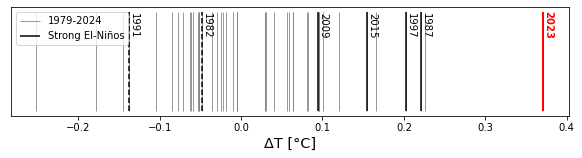

In [57]:
# Assuming dGMST.t2m and dGMST.year exist


composite_years = [1982, 1987, 1991, 1997, 2015, 2009]
dGMST_composite = dGMST.where(dGMST.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dGMST.t2m, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dGMST.sel(year = 1982).t2m, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dGMST.sel(year = 1987).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dGMST.sel(year = 1991).t2m, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dGMST.sel(year = 1997).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dGMST.sel(year = 2009).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dGMST.sel(year = 2015).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)


for y in dGMST_composite.year.values: 
    x = dGMST.sel(year = y).t2m
    ax.annotate(y, (x, 0.75), rotation = 270)
        

x = dGMST.sel(year= 2023).t2m
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.vlines(x, ymin=0, ymax = 0, color = 'k', linewidth = 1.5, label = 'Strong El-Niños')
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔT [°C]", fontweight = 'normal')
#ax.set_title("Barcode Plot of dGMST.t2m")

plt.legend(loc = 'upper left')
fig.savefig('temp/Fig1a.png', dpi = 600, format = 'png', bbox_inches='tight')

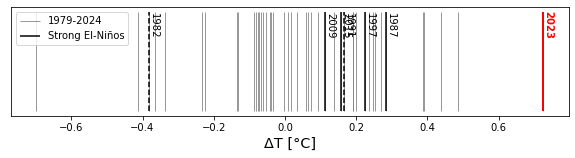

In [58]:
# Assuming dGLST.t2m and dGLST.year exist


composite_years = [1982, 1987, 1991, 1997, 2015, 2009]
dGLST_composite = dGLST.where(dGLST.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dGLST.t2m, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dGLST.sel(year = 1982).t2m, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dGLST.sel(year = 1987).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dGLST.sel(year = 1991).t2m, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dGLST.sel(year = 1997).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dGLST.sel(year = 2009).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dGLST.sel(year = 2015).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)


for y in dGLST_composite.year.values: 
    x = dGLST.sel(year = y).t2m
    ax.annotate(y, (x, 0.75), rotation = 270)
        

x = dGLST.sel(year= 2023).t2m
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.vlines(x, ymin=0, ymax = 0, color = 'k', linewidth = 1.5, label = 'Strong El-Niños')
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔT [°C]", fontweight = 'normal')
#ax.set_title("Barcode Plot of dGLST.t2m")

plt.legend(loc = 'upper left')
#fig.savefig('Figures/Fig1a.png', dpi = 600, format = 'png', bbox_inches='tight')